In [1]:
# Gerekli kütüphaneler 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Temizlenmiş veri setinin yüklenmesi
veri = pd.read_csv("../data/telco_temiz.csv")

In [3]:
# Veri setinin ilk 5 satırını görüntüleme
veri.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Veri setinin boyutunu görüntüleme
veri.shape

(7032, 21)

In [5]:
# Veri seti hakkında genel bilgi
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


## Hedef Değişken Analizi (Churn)

In [7]:
# Hedef değişkeninin dağılımının incelenmesi

In [8]:
# Frekans dağılımı
veri["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [9]:
# Yüzdesel dağılım
round(veri["Churn"].value_counts(normalize=True) * 100, 2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

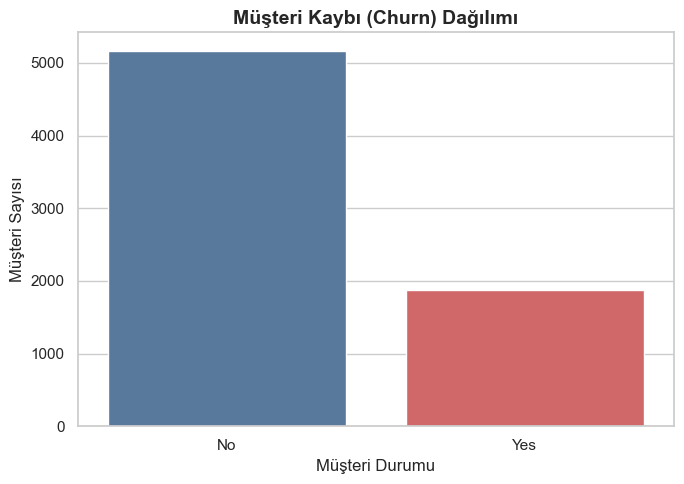

In [18]:
# Hedef değişkenin görselleştirilmesi

plt.figure(figsize=(7,5))

sns.countplot(
    data=veri,
    x="Churn",
    hue="Churn",
    palette={
        "No": "#4E79A7",
        "Yes": "#E15759"
    },
    legend=False
)

plt.title("Müşteri Kaybı (Churn) Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("Müşteri Durumu", fontsize=12)
plt.ylabel("Müşteri Sayısı", fontsize=12)

plt.tight_layout()
plt.show()

## Sayısal Değişken Analizi

### Hizmet Kullanım Süresi (tenure)

In [22]:
# tenure değişkeninin temel istatistikleri

veri["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

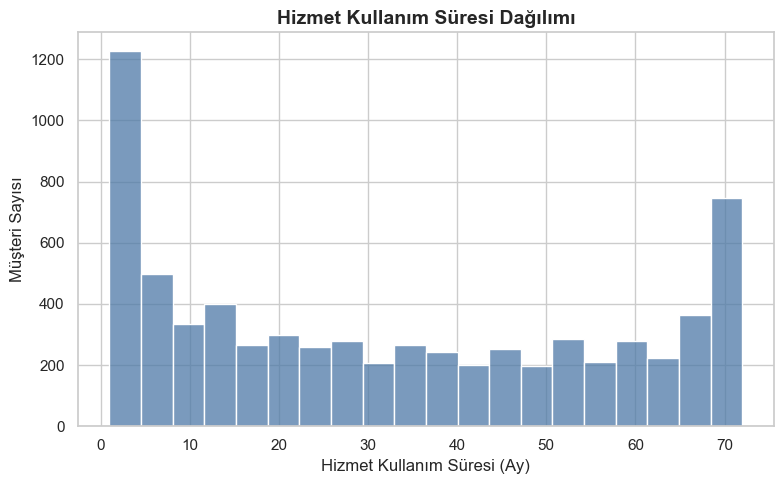

In [24]:
# tenure değişkeninin dağılımı

plt.figure(figsize=(8,5))

sns.histplot(
    data=veri,
    x="tenure",
    bins=20,
    color="#4E79A7"
)

plt.title("Hizmet Kullanım Süresi Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("Hizmet Kullanım Süresi (Ay)", fontsize=12)
plt.ylabel("Müşteri Sayısı", fontsize=12)

plt.tight_layout()
plt.show()

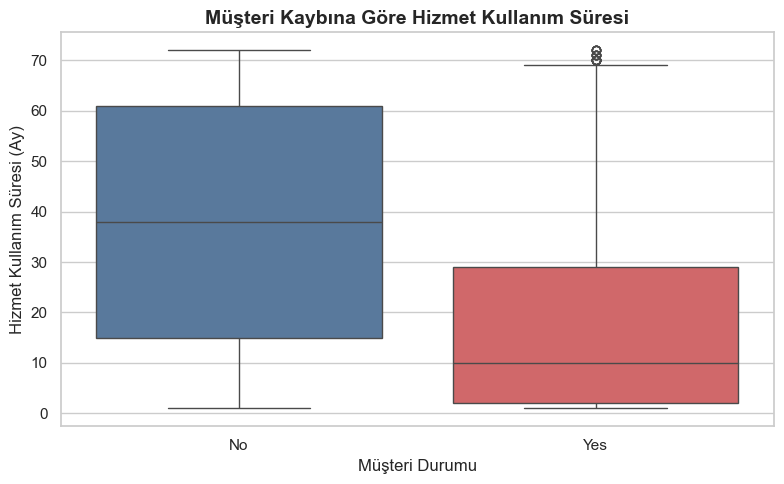

In [25]:
# Hizmet kullanım süresinin müşteri kaybına göre karşılaştırılması

plt.figure(figsize=(8,5))

sns.boxplot(
    data=veri,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette={
        "No": "#4E79A7",
        "Yes": "#E15759"
    },
    legend=False
)

plt.title("Müşteri Kaybına Göre Hizmet Kullanım Süresi", fontsize=14, fontweight="bold")
plt.xlabel("Müşteri Durumu", fontsize=12)
plt.ylabel("Hizmet Kullanım Süresi (Ay)", fontsize=12)

plt.tight_layout()
plt.show()

### Aylık Ödeme Tutarı (MonthlyCharges)

In [28]:
# MonthlyCharges değişkeninin temel istatistikleri

veri["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

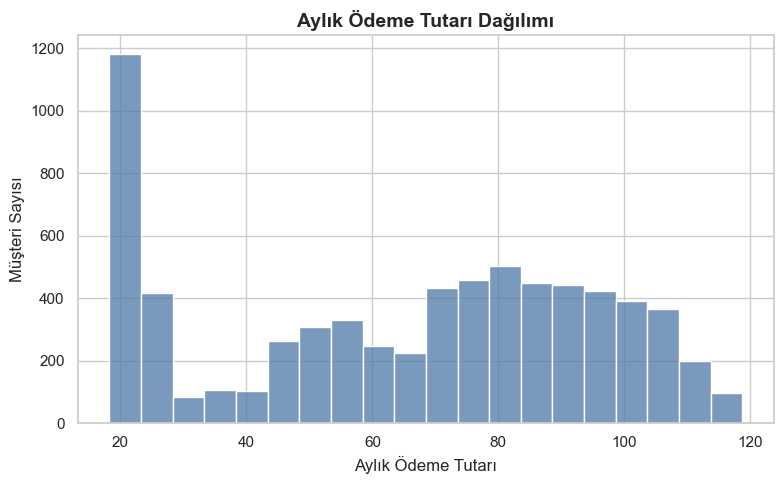

In [31]:
# MonthlyCharges değişkeninin dağılımı

plt.figure(figsize=(8,5))

sns.histplot(
    data=veri,
    x="MonthlyCharges",
    bins=20,
    color="#4E79A7"
)

plt.title("Aylık Ödeme Tutarı Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("Aylık Ödeme Tutarı", fontsize=12)
plt.ylabel("Müşteri Sayısı", fontsize=12)

plt.tight_layout()
plt.show()

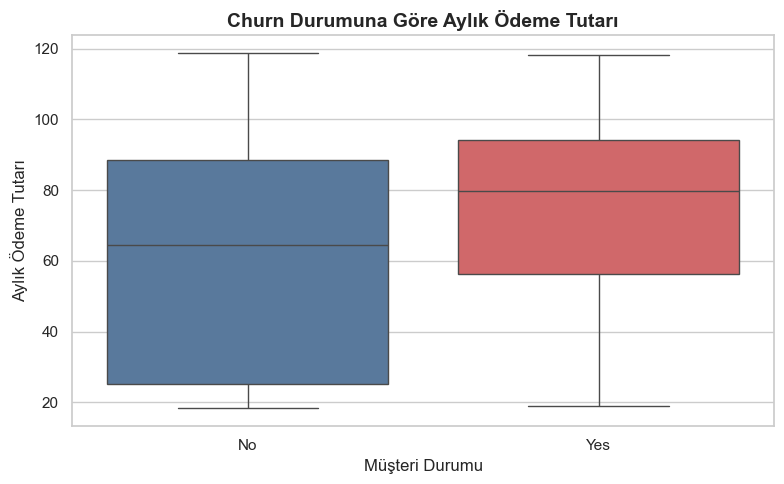

In [32]:
# Aylık ödeme tutarının müşteri kaybına göre karşılaştırılması

plt.figure(figsize=(8,5))

sns.boxplot(
    data=veri,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette={
        "No": "#4E79A7",
        "Yes": "#E15759"
    },
    legend=False
)

plt.title("Churn Durumuna Göre Aylık Ödeme Tutarı", fontsize=14, fontweight="bold")
plt.xlabel("Müşteri Durumu", fontsize=12)
plt.ylabel("Aylık Ödeme Tutarı", fontsize=12)

plt.tight_layout()
plt.show()

### Toplam Ödeme Tutarı (TotalCharges)

In [36]:
# TotalCharges değişkeninin temel istatistikleri

veri["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

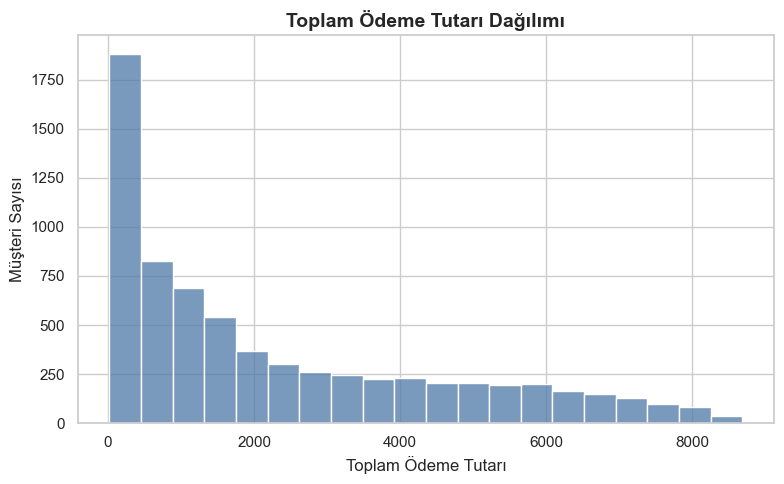

In [38]:
# TotalCharges değişkeninin dağılımı

plt.figure(figsize=(8,5))

sns.histplot(
    data=veri,
    x="TotalCharges",
    bins=20,
    color="#4E79A7"
)

plt.title("Toplam Ödeme Tutarı Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("Toplam Ödeme Tutarı", fontsize=12)
plt.ylabel("Müşteri Sayısı", fontsize=12)

plt.tight_layout()
plt.show()

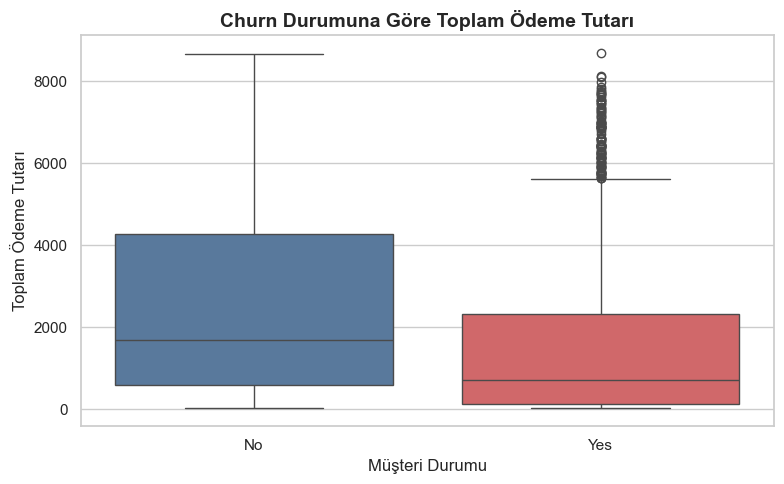

In [40]:
# Toplam ödeme tutarının müşteri kaybına göre karşılaştırılması

plt.figure(figsize=(8,5))

sns.boxplot(
    data=veri,
    x="Churn",
    y="TotalCharges",
    hue="Churn",
    palette={
        "No": "#4E79A7",
        "Yes": "#E15759"
    },
    legend=False
)

plt.title("Churn Durumuna Göre Toplam Ödeme Tutarı", fontsize=14, fontweight="bold")
plt.xlabel("Müşteri Durumu", fontsize=12)
plt.ylabel("Toplam Ödeme Tutarı", fontsize=12)

plt.tight_layout()
plt.show()

## Kategorik Değişken Analizi

### Sözleşme Türü (Contract)

In [50]:
# Sözleşme türlerinin dağılımı

veri["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

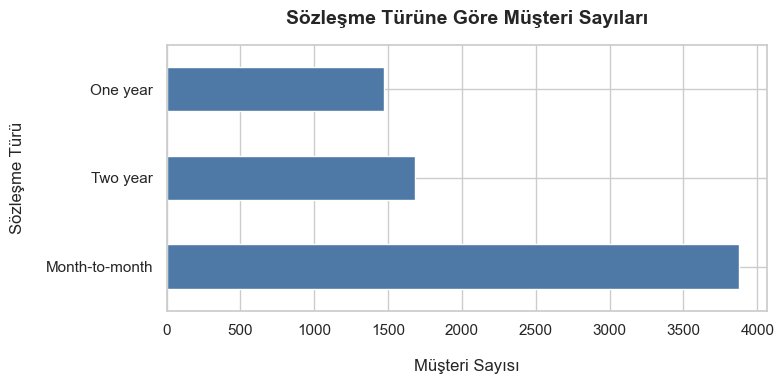

In [231]:
# Sözleşme türlerinin dağılımı

veri["Contract"].value_counts().plot(
    kind="barh",
    figsize=(8, 4),
    color="#4E79A7"
)

plt.title("Sözleşme Türüne Göre Müşteri Sayıları",
          fontsize=14,
          fontweight="bold",
          pad=15
         )
plt.xlabel("Müşteri Sayısı" , labelpad=15)
plt.ylabel("Sözleşme Türü" , labelpad=15)
plt.tight_layout()
plt.show()

In [124]:
# Sözleşme türüne göre müşteri kaybı oranı

pd.crosstab(
    veri["Contract"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


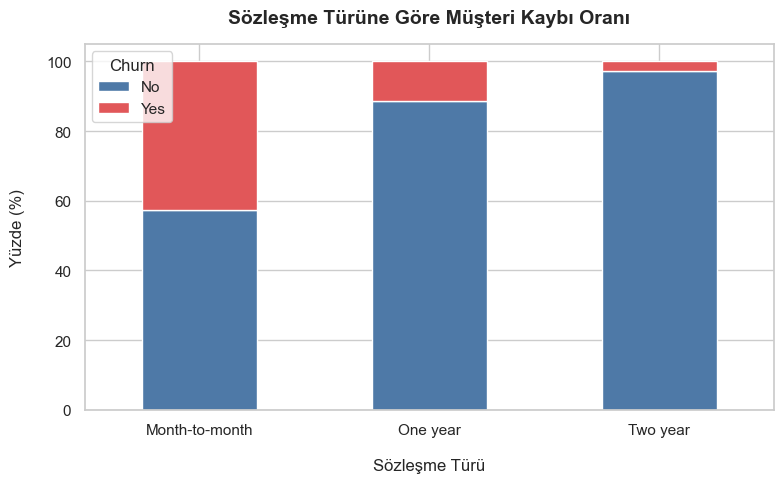

In [233]:
# Sözleşme türüne göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["Contract"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=renkler
)
plt.xticks(rotation=0)
plt.title("Sözleşme Türüne Göre Müşteri Kaybı Oranı", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Sözleşme Türü", fontsize=12 , labelpad=15)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### İnternet Hizmeti Türü (InternetService)

In [56]:
# İnternet hizmeti türlerinin dağılımı

veri["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

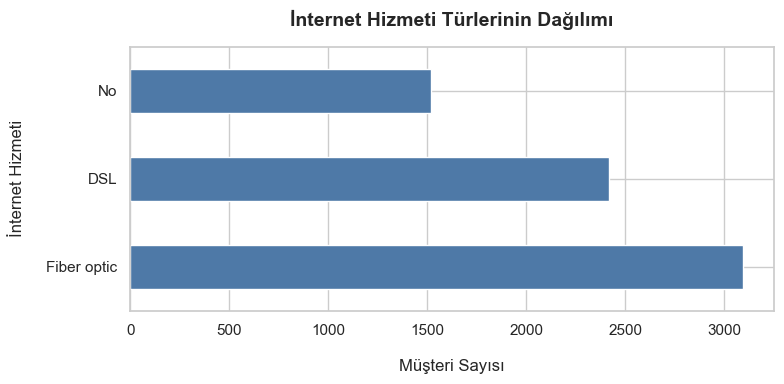

In [227]:
# İnternet hizmeti türlerinin dağılımı

veri["InternetService"].value_counts().plot(
    kind="barh",
    figsize=(8, 4),
    color="#4E79A7"
)

plt.title("İnternet Hizmeti Türlerinin Dağılımı" ,
    fontsize=14,
    fontweight="bold",
    pad=15        
         )

plt.xlabel("Müşteri Sayısı" , labelpad=15)
plt.ylabel("İnternet Hizmeti" , labelpad=15)
plt.tight_layout()
plt.show()

In [58]:
# İnternet hizmeti türüne göre müşteri kaybı oranı

pd.crosstab(
    veri["InternetService"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


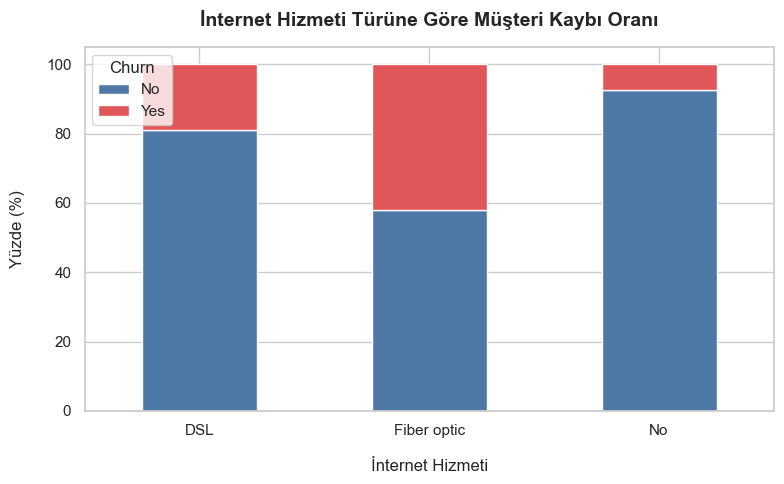

In [229]:
# İnternet hizmeti türüne göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["InternetService"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=renkler
)
plt.xticks(rotation=0)
plt.title("İnternet Hizmeti Türüne Göre Müşteri Kaybı Oranı",
          fontsize=14,
          fontweight="bold",
          pad=15
         )

plt.xlabel("İnternet Hizmeti", fontsize=12 , labelpad=15)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)

plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### Ödeme Yöntemi (PaymentMethod)

In [63]:
# Ödeme yöntemlerinin dağılımı

veri["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

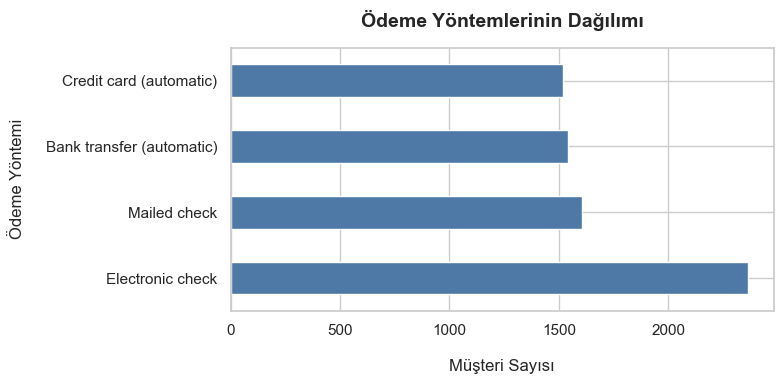

In [221]:
# Ödeme yöntemlerinin dağılımı

veri["PaymentMethod"].value_counts().plot(
    kind="barh",
    figsize=(8, 4),
    color="#4E79A7"
)

plt.title("Ödeme Yöntemlerinin Dağılımı" ,
    fontsize=14,
    fontweight="bold",
    pad=15        
         )

plt.xlabel("Müşteri Sayısı" , labelpad=15)
plt.ylabel("Ödeme Yöntemi" , labelpad=15)
plt.tight_layout()
plt.show()

In [65]:
# Ödeme yöntemine göre müşteri kaybı oranı

pd.crosstab(
    veri["PaymentMethod"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.7,15.3
Electronic check,54.7,45.3
Mailed check,80.8,19.2


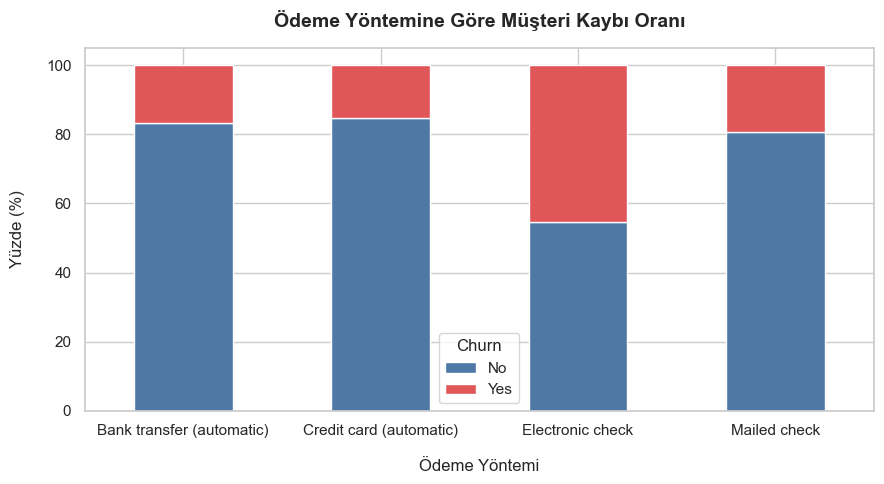

In [225]:
# Ödeme yöntemine göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["PaymentMethod"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=renkler
)

plt.title("Ödeme Yöntemine Göre Müşteri Kaybı Oranı",
          fontsize=14,
          fontweight="bold",
          pad=15  
         )

plt.xlabel("Ödeme Yöntemi", fontsize=12 , labelpad=15)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)

plt.legend(title="Churn")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Online Güvenlik (OnlineSecurity)

In [72]:
# OnlineSecurity değişkeninin dağılımı

veri["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

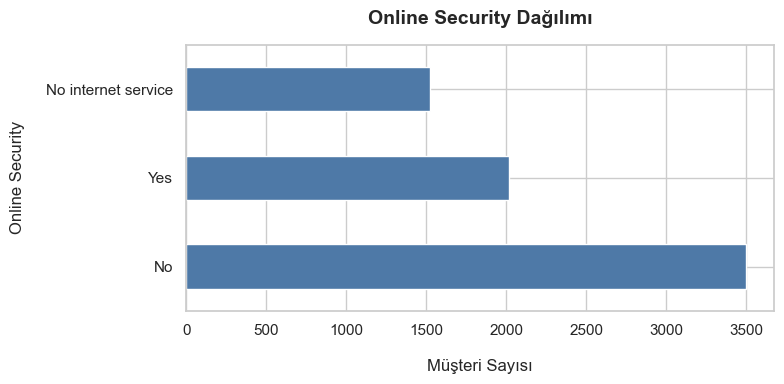

In [217]:
# OnlineSecurity değişkeninin dağılımı

veri["OnlineSecurity"].value_counts().plot(
    kind="barh",
    figsize=(8, 4),
    color="#4E79A7"
)

plt.title("Online Security Dağılımı" ,
    fontsize=14,
    fontweight="bold",
    pad=15
         )

plt.xlabel("Müşteri Sayısı" , labelpad=15)
plt.ylabel("Online Security" , labelpad=15)
plt.tight_layout()
plt.show()

In [74]:
# OnlineSecurity durumuna göre müşteri kaybı oranı

pd.crosstab(
    veri["OnlineSecurity"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6


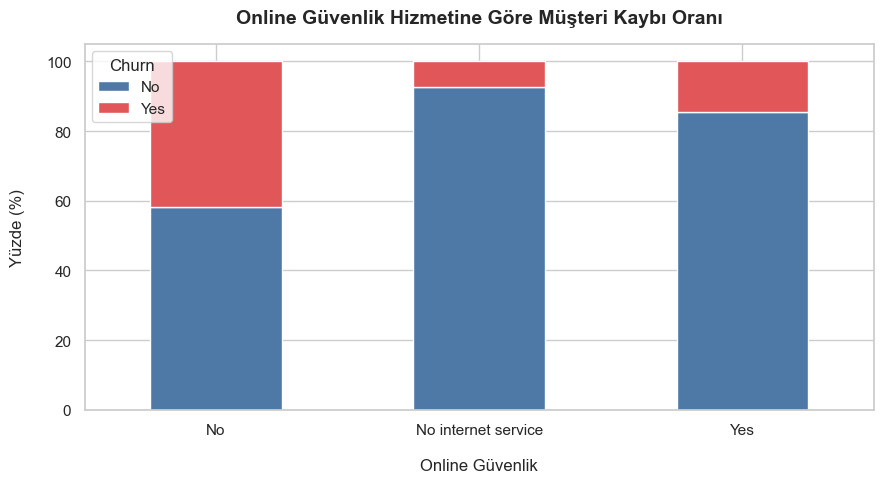

In [219]:
# OnlineSecurity durumuna göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["OnlineSecurity"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=renkler
)

plt.title(
    "Online Güvenlik Hizmetine Göre Müşteri Kaybı Oranı",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Online Güvenlik", fontsize=12 , labelpad=15)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)

plt.legend(title="Churn")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Teknik Destek (TechSupport)

In [108]:
# Teknik destek hizmetinin dağılımı

veri["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

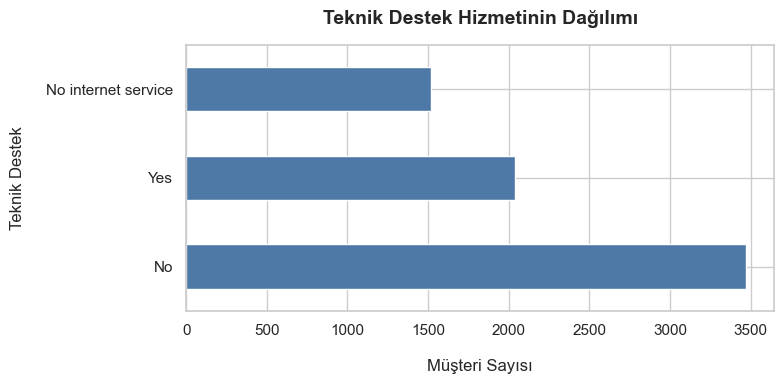

In [211]:
# Teknik destek hizmetinin dağılımı

veri["TechSupport"].value_counts().plot(
    kind="barh",
    figsize=(8, 4),
    color="#4E79A7"
)

plt.title("Teknik Destek Hizmetinin Dağılımı" ,
    fontsize=14,
    fontweight="bold",
    pad=15
         )
plt.xlabel("Müşteri Sayısı" , labelpad=15)
plt.ylabel("Teknik Destek" , labelpad=15)
plt.tight_layout()
plt.show()

In [81]:
# Teknik destek durumuna göre müşteri kaybı oranı

pd.crosstab(
    veri["TechSupport"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2


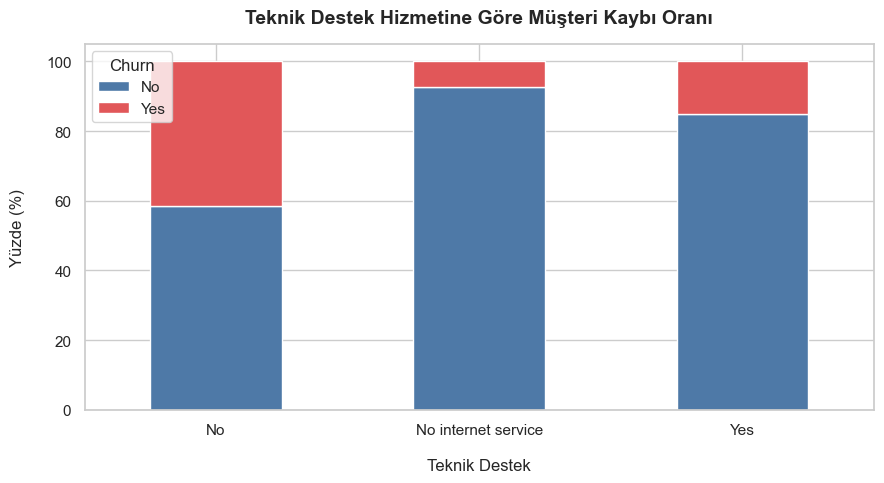

In [215]:
# Teknik destek durumuna göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["TechSupport"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=renkler
)

plt.title(
    "Teknik Destek Hizmetine Göre Müşteri Kaybı Oranı",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xticks(rotation=0)
plt.xlabel("Teknik Destek" , labelpad=15 , fontsize=12)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)

plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### Kağıtsız Faturalandırma (PaperlessBilling)

In [87]:
# Kağıtsız faturalandırma durumunun dağılımı

veri["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

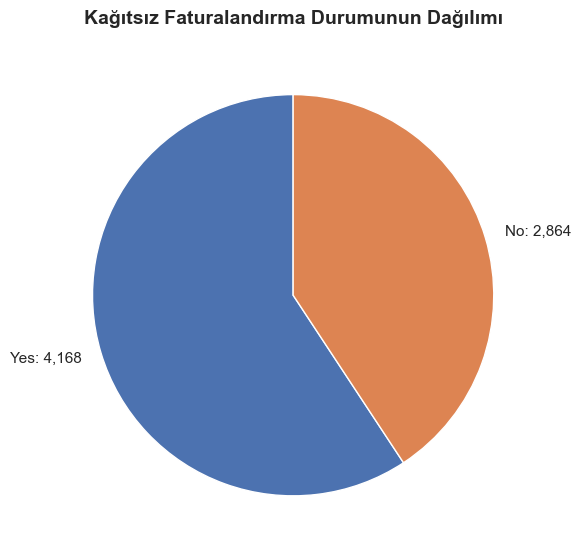

In [209]:
# Kağıtsız faturalandırma durumunun dağılımı

degerler = veri["PaperlessBilling"].value_counts()

degerler.plot(
    kind="pie",
    figsize=(6, 6),
    labels=[f"{kategori}: {sayi:,}" for kategori, sayi in degerler.items()],
    startangle=90
)

plt.title("Kağıtsız Faturalandırma Durumunun Dağılımı" ,
                fontsize=14,
    fontweight="bold",
    pad=15
         )

plt.ylabel("")
plt.tight_layout()
plt.show()

In [89]:
# Kağıtsız faturalandırma durumuna göre müşteri kaybı oranı

pd.crosstab(
    veri["PaperlessBilling"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.6,16.4
Yes,66.4,33.6


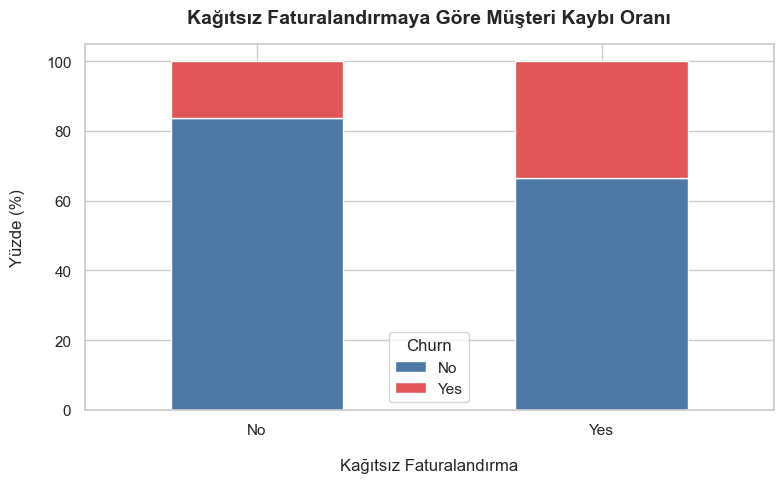

In [207]:
# Kağıtsız faturalandırma durumuna göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["PaperlessBilling"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=renkler
)

plt.title(
    "Kağıtsız Faturalandırmaya Göre Müşteri Kaybı Oranı",
    fontsize=14,
    fontweight="bold",
    pad = 15
)

plt.xlabel("Kağıtsız Faturalandırma", fontsize=12 , labelpad=15)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)

plt.legend(title="Churn")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Yaşlı Müşteri Durumu (SeniorCitizen)

In [94]:
# Yaşlı müşteri durumunun dağılımı

veri["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

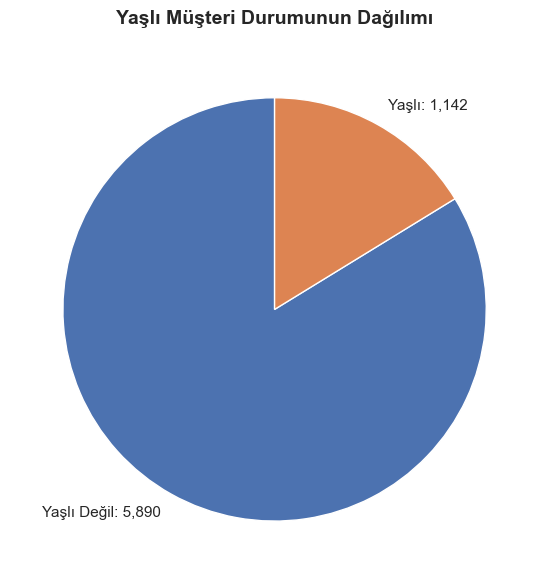

In [204]:
# Yaşlı müşteri durumunun dağılımı

degerler = veri["SeniorCitizen"].value_counts()

etiketler = {
    0: "Yaşlı Değil",
    1: "Yaşlı"
}

degerler.index = degerler.index.map(etiketler)

degerler.plot(
    kind="pie",
    figsize=(6, 6),
    labels=[f"{kategori}: {sayi:,}" for kategori, sayi in degerler.items()],
    startangle=90
)

plt.title("Yaşlı Müşteri Durumunun Dağılımı" ,
          fontsize=14,
    fontweight="bold",
    pad=15
    )

plt.ylabel("")
plt.tight_layout()
plt.show()

In [194]:
# Yaşlı müşteri durumuna göre müşteri kaybı oranı

pd.crosstab(
    veri["SeniorCitizen"],
    veri["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.3,23.7
1,58.3,41.7


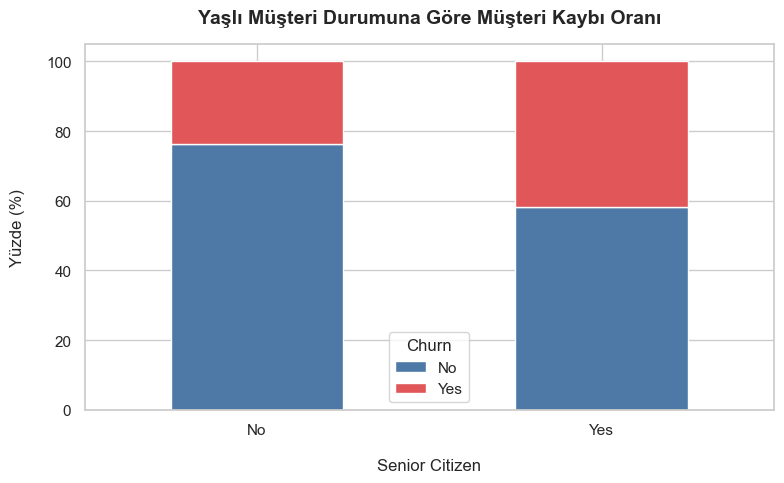

In [235]:
# Yaşlı müşteri durumuna göre müşteri kaybı oranlarının görselleştirilmesi

oranlar = pd.crosstab(
    veri["SeniorCitizen"],
    veri["Churn"],
    normalize="index"
) * 100

renkler = ["#4E79A7", "#E15759"]

ax = oranlar.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=renkler
)

ax.set_xticklabels(["No", "Yes"], rotation=0)

plt.title(
    "Yaşlı Müşteri Durumuna Göre Müşteri Kaybı Oranı",
    fontsize=14,
    fontweight="bold",
    pad=15
    
)

plt.xlabel("Senior Citizen", fontsize=12 , labelpad=15)
plt.ylabel("Yüzde (%)", fontsize=12 , labelpad=15)

plt.legend(title="Churn")

plt.tight_layout()
plt.show()

## Sayısal Değişkenler Arasındaki İlişkiler

In [242]:
veri[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


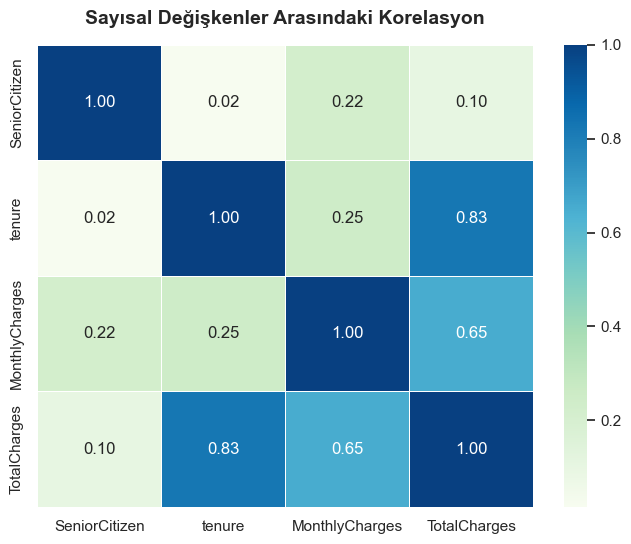

In [246]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    veri[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="GnBu",
    linewidths=0.5
)

plt.title("Sayısal Değişkenler Arasındaki Korelasyon" , pad=15 , fontsize=14 , fontweight="bold")
plt.show()